<a href="https://colab.research.google.com/github/Annette-1/SIMULACION-II/blob/main/cadenas_buenas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cadenas buenas: valor esperado de 1s con Monte Carlo y cadenas de Markov

Una **buena cadena** de longitud $m$ es una secuencia de 0s y 1s **sin 1s adyacentes**.

**Pregunta:** si todas las buenas cadenas son igualmente probables, ¿cuál es el número esperado de 1s?

$$\mu = \sum_k k\,\pi_k, \qquad \pi_k = P(\text{una buena cadena tenga } k \text{ unos})$$

**Contenido**
1. Definición y enumeración exacta (caso $m=4$)
2. Fórmula exacta para $m$ general (para validar las simulaciones)
3. Método de aceptación y rechazo (y por qué no es viable para $m$ grande)
4. Cadena de Markov (paseo aleatorio en el grafo ponderado) y su matriz de transición
5. Estimación Monte Carlo con la cadena de Markov
6. Conclusiones

In [1]:
import itertools
import random
from math import comb

import numpy as np
import matplotlib.pyplot as plt

random.seed(2026)
np.random.seed(2026)

## 1. Definición y enumeración exacta

Hay $2^m$ secuencias en total (principio fundamental del conteo: 2 opciones por posición).
Para $m=4$ son $2^4=16$, de las cuales solo 8 son buenas.

In [2]:
def es_buena(cadena):
    '''True si la cadena (tupla/lista de 0 y 1) no tiene dos 1s adyacentes.'''
    return all(not (a == 1 and b == 1) for a, b in zip(cadena, cadena[1:]))


def enumerar_buenas(m):
    '''Genera todas las buenas cadenas de longitud m (fuerza bruta, solo m pequeño).'''
    return [c for c in itertools.product((0, 1), repeat=m) if es_buena(c)]


m = 4
buenas = enumerar_buenas(m)
print(f"Total de cadenas: {2**m}")
print(f"Buenas cadenas  : {len(buenas)}")
for c in buenas:
    print("".join(map(str, c)), " -> unos:", sum(c))

mu_exacta_4 = np.mean([sum(c) for c in buenas])
print(f"\nValor esperado exacto de 1s para m=4: {mu_exacta_4}")

Total de cadenas: 16
Buenas cadenas  : 8
0000  -> unos: 0
0001  -> unos: 1
0010  -> unos: 1
0100  -> unos: 1
0101  -> unos: 2
1000  -> unos: 1
1001  -> unos: 2
1010  -> unos: 2

Valor esperado exacto de 1s para m=4: 1.25


Las 8 buenas cadenas son $0000, 1000, 0100, 0010, 0001, 1010, 0101, 1001$ (coincide con la lista del cuaderno).
Hay 1 con cero 1s, 4 con un 1 y 3 con dos 1s, así que $\mu = (0\cdot1+1\cdot4+2\cdot3)/8 = 10/8 = 1.25$.

## 2. Fórmula exacta para $m$ general

El número de buenas cadenas con exactamente $k$ unos es $\binom{m-k+1}{k}$
(se colocan los $k$ unos en los $m-k+1$ "huecos" que dejan los ceros). Entonces

$$N_m = \sum_k \binom{m-k+1}{k} = F_{m+2} \quad(\text{números de Fibonacci}),\qquad
\pi_k = \frac{\binom{m-k+1}{k}}{N_m},\qquad \mu=\sum_k k\,\pi_k .$$

Esto nos da el valor verdadero para comparar contra Monte Carlo, incluso con $m=100$.

In [3]:
def distribucion_exacta(m):
    '''Devuelve (N, pi) donde N = # de buenas cadenas y pi[k] = P(k unos).'''
    conteos = [comb(m - k + 1, k) if m - k + 1 >= k else 0 for k in range(m + 1)]
    N = sum(conteos)
    pi = [c / N for c in conteos]   # Python usa enteros grandes; la división es exacta en float
    return N, pi


def media_exacta(m):
    N, pi = distribucion_exacta(m)
    return sum(k * p for k, p in enumerate(pi))


# Verificación contra la enumeración por fuerza bruta
for m in range(1, 13):
    bf = enumerar_buenas(m)
    N, _ = distribucion_exacta(m)
    assert N == len(bf)
    assert abs(media_exacta(m) - np.mean([sum(c) for c in bf])) < 1e-12
print("Fórmula verificada contra fuerza bruta para m = 1..12")

for m in (4, 10, 20, 100):
    N, _ = distribucion_exacta(m)
    print(f"m={m:>3}: buenas cadenas = {N:.3e}   mu exacta = {media_exacta(m):.4f}")

Fórmula verificada contra fuerza bruta para m = 1..12
m=  4: buenas cadenas = 8.000e+00   mu exacta = 1.2500
m= 10: buenas cadenas = 1.440e+02   mu exacta = 2.9167
m= 20: buenas cadenas = 1.771e+04   mu exacta = 5.6807
m=100: buenas cadenas = 9.274e+20   mu exacta = 27.7921


## 3. Aceptación y rechazo

Se generan secuencias uniformes entre las $2^m$ y **solo se guardan las buenas**.
La probabilidad de aceptar es $N_m/2^m$.

In [4]:
def muestra_aceptacion_rechazo(m, n_buenas, max_intentos=10_000_000):
    '''Genera cadenas uniformes y conserva solo las buenas. Devuelve (muestras, intentos).'''
    buenas, intentos = [], 0
    while len(buenas) < n_buenas and intentos < max_intentos:
        c = np.random.randint(0, 2, size=m)
        intentos += 1
        if not np.any(c[:-1] & c[1:]):
            buenas.append(int(c.sum()))
    return buenas, intentos


for m in (4, 10, 20):
    unos, intentos = muestra_aceptacion_rechazo(m, n_buenas=2000)
    N, _ = distribucion_exacta(m)
    print(f"m={m:>2}: tasa de aceptación empírica = {len(unos)/intentos:.4f} "
          f"(teórica {N/2**m:.4f}) | mu estimada = {np.mean(unos):.3f} (exacta {media_exacta(m):.3f})")

# Caso m = 100: la tasa teórica de aceptación
N100, _ = distribucion_exacta(100)
print(f"\nm=100: 2^100 = {2**100:.2e}, buenas = {N100:.2e}, proporción = {N100/2**100:.2e}")
print("Se encuentra una buena cadena cada ~", f"{2**100/N100:.2e}", "intentos -> procedimiento NO viable")

m= 4: tasa de aceptación empírica = 0.4964 (teórica 0.5000) | mu estimada = 1.258 (exacta 1.250)
m=10: tasa de aceptación empírica = 0.1403 (teórica 0.1406) | mu estimada = 2.922 (exacta 2.917)
m=20: tasa de aceptación empírica = 0.0174 (teórica 0.0169) | mu estimada = 5.714 (exacta 5.681)

m=100: 2^100 = 1.27e+30, buenas = 9.27e+20, proporción = 7.32e-10
Se encuentra una buena cadena cada ~ 1.37e+09 intentos -> procedimiento NO viable


Para $m=100$: $2^{100}\approx10^{30}$ y hay unas $10^{21}$ buenas cadenas, por lo que la proporción es
$\approx 10^{-9}$ (una buena cada mil millones de intentos). Por eso necesitamos otro método.

## 4. Cadena de Markov (paseo aleatorio en el grafo)

**Reglas del paso** (desde una buena cadena $x$ de longitud $m$):

1. Elegir uniformemente al azar una de las $m$ posiciones.
2. Si el componente es **1**, se cambia a **0** (el resultado siempre es buena) y el paseo se mueve.
3. Si el componente es **0**, se cambia a **1** solo si la cadena resultante es buena; si no, el paseo **se queda** en $x$.

**Grafo ponderado equivalente:** dos buenas cadenas que difieren en una sola posición están unidas por una arista de peso 1,
y cada vértice tiene un lazo cuyo peso es tal que la suma de pesos incidentes sea $m$:

$$w_{\text{lazo}}(x) = m - \text{grado}(x).$$

Como todos los vértices tienen el mismo peso total $m$, la matriz de transición $P(x,y)=w(x,y)/m$ es simétrica
y la **distribución estacionaria es uniforme**, que es justo lo que queremos.

In [5]:
def matriz_transicion(m):
    '''Construye P (|buenas| x |buenas|) y la lista de estados para m pequeño.'''
    estados = ["".join(map(str, c)) for c in enumerar_buenas(m)]
    idx = {s: i for i, s in enumerate(estados)}
    n = len(estados)
    W = np.zeros((n, n))                      # pesos del grafo
    for s in estados:
        for j in range(m):
            t = s[:j] + ("0" if s[j] == "1" else "1") + s[j + 1:]
            if t in idx:                      # vecino bueno -> arista de peso 1
                W[idx[s], idx[t]] = 1
    grado = W.sum(axis=1)
    for s in estados:                         # lazo = m - grado
        W[idx[s], idx[s]] = m - grado[idx[s]]
    return estados, W, W / m


estados, W, P = matriz_transicion(4)

print("Pesos de los lazos (comparar con la Figura 5.1):")
for s, i in zip(estados, range(len(estados))):
    print(f"  {s}: lazo = {int(W[i, i])}")

print("\nSuma de pesos incidentes por vértice:", set(W.sum(axis=1)))
print("P simétrica:", np.allclose(P, P.T), "| filas suman 1:", np.allclose(P.sum(axis=1), 1))

# Distribución estacionaria: vector propio izquierdo de valor propio 1
vals, vecs = np.linalg.eig(P.T)
pi = np.real(vecs[:, np.argmin(abs(vals - 1))]); pi = pi / pi.sum()
print("Distribución estacionaria:", np.round(pi, 4), "(uniforme = 1/8 = 0.125)")

Pesos de los lazos (comparar con la Figura 5.1):
  0000: lazo = 0
  0001: lazo = 1
  0010: lazo = 2
  0100: lazo = 2
  0101: lazo = 2
  1000: lazo = 1
  1001: lazo = 2
  1010: lazo = 2

Suma de pesos incidentes por vértice: {np.float64(4.0)}
P simétrica: True | filas suman 1: True
Distribución estacionaria: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125] (uniforme = 1/8 = 0.125)


Los lazos de la figura se reproducen: $1001, 1010, 0101, 0010, 0100$ tienen lazo 2 y $1000, 0001$ tienen lazo 1.
La cadena $0000$ tiene 4 vecinos y lazo 0. Se verifica además que la distribución estacionaria es uniforme.

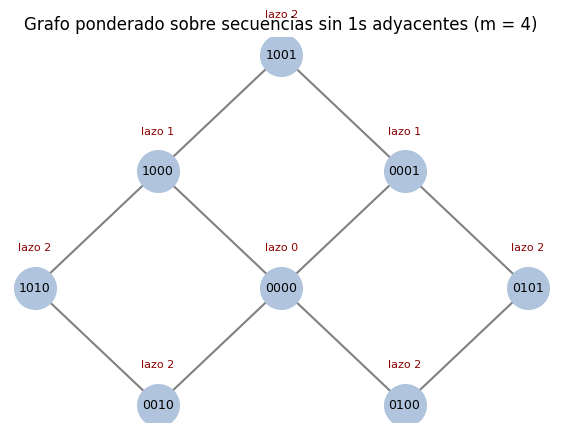

In [6]:
# Dibujo del grafo para m = 4 (posiciones a mano, igual que la Figura 5.1)
pos = {"1001": (0, 3), "1000": (-1.5, 2), "0001": (1.5, 2),
       "1010": (-3, 1), "0000": (0, 1), "0101": (3, 1),
       "0010": (-1.5, 0), "0100": (1.5, 0)}

fig, ax = plt.subplots(figsize=(7, 5))
idx = {s: i for i, s in enumerate(estados)}
for s in estados:
    for t in estados:
        if s < t and W[idx[s], idx[t]] == 1:
            ax.plot(*zip(pos[s], pos[t]), color="gray", zorder=1)
for s in estados:
    x, y = pos[s]
    ax.scatter(x, y, s=900, color="lightsteelblue", zorder=2)
    ax.text(x, y, s, ha="center", va="center", fontsize=9, zorder=3)
    ax.text(x, y + 0.32, f"lazo {int(W[idx[s], idx[s]])}", ha="center", fontsize=8, color="darkred")
ax.set_title("Grafo ponderado sobre secuencias sin 1s adyacentes (m = 4)")
ax.axis("off"); plt.show()

## 5. Estimación Monte Carlo con la cadena de Markov

Simulamos $Y_0, Y_1, Y_2,\dots$ siguiendo el paseo y estimamos

$$\mu \approx \frac{r(Y_0)+r(Y_1)+\cdots+r(Y_n)}{n}, \qquad r(Y)=\text{número de 1s de } Y.$$

Para $m$ grande, cada paso se implementa en $O(1)$: basta revisar los vecinos izquierdo y derecho de la posición elegida
y mantener un contador de unos. Se descarta un periodo de calentamiento (*burn-in*) al inicio.

In [7]:
def paso(y, n_unos, m):
    '''Un paso del paseo aleatorio. Modifica y (lista) en sitio y devuelve el nuevo n_unos.'''
    j = random.randrange(m)
    if y[j] == 1:                         # 1 -> 0: siempre permitido
        y[j] = 0
        return n_unos - 1
    izq = y[j - 1] if j > 0 else 0        # 0 -> 1: solo si no crea 1s adyacentes
    der = y[j + 1] if j < m - 1 else 0
    if izq == 0 and der == 0:
        y[j] = 1
        return n_unos + 1
    return n_unos                         # rechazado: el paseo se queda (lazo)


def monte_carlo_markov(m, n_pasos, burn_in=None):
    '''Estima mu promediando r(Y_t) a lo largo del paseo. Inicia en la cadena 00...0.'''
    if burn_in is None:
        burn_in = 10 * m
    y, n_unos = [0] * m, 0
    for _ in range(burn_in):
        n_unos = paso(y, n_unos, m)
    suma = 0
    historial = np.empty(n_pasos)
    for t in range(n_pasos):
        n_unos = paso(y, n_unos, m)
        suma += n_unos
        historial[t] = suma / (t + 1)     # promedio acumulado
    assert es_buena(y)                    # sanity check: nunca salimos de las buenas
    return suma / n_pasos, historial


for m, n in ((4, 200_000), (10, 200_000), (100, 1_000_000)):
    est, _ = monte_carlo_markov(m, n)
    ex = media_exacta(m)
    print(f"m={m:>3} | n={n:>9,} | estimada = {est:8.4f} | exacta = {ex:8.4f} | error = {abs(est-ex):.4f}")

m=  4 | n=  200,000 | estimada =   1.2517 | exacta =   1.2500 | error = 0.0017
m= 10 | n=  200,000 | estimada =   2.9097 | exacta =   2.9167 | error = 0.0069
m=100 | n=1,000,000 | estimada =  27.7823 | exacta =  27.7921 | error = 0.0098


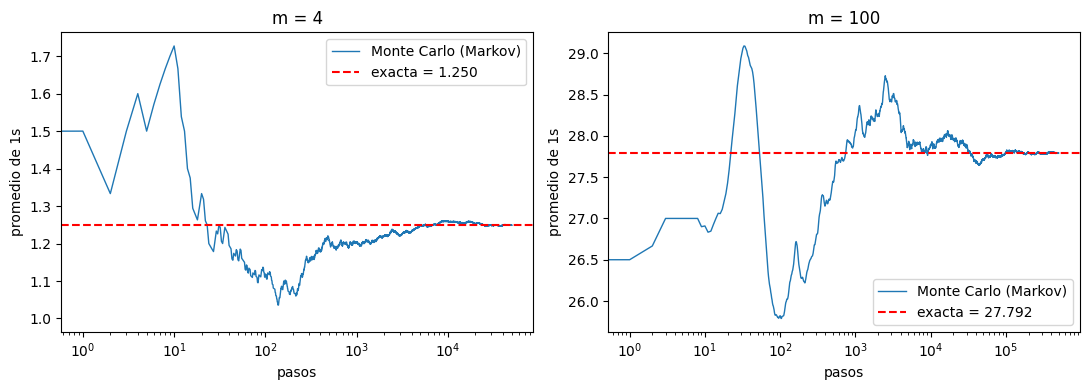

In [8]:
# Convergencia del promedio acumulado hacia el valor exacto
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, n in zip(axes, (4, 100), (50_000, 500_000)):
    _, h = monte_carlo_markov(m, n)
    ax.plot(h, lw=1, label="Monte Carlo (Markov)")
    ax.axhline(media_exacta(m), color="red", ls="--", label=f"exacta = {media_exacta(m):.3f}")
    ax.set_xscale("log"); ax.set_xlabel("pasos"); ax.set_ylabel("promedio de 1s")
    ax.set_title(f"m = {m}"); ax.legend()
plt.tight_layout(); plt.show()

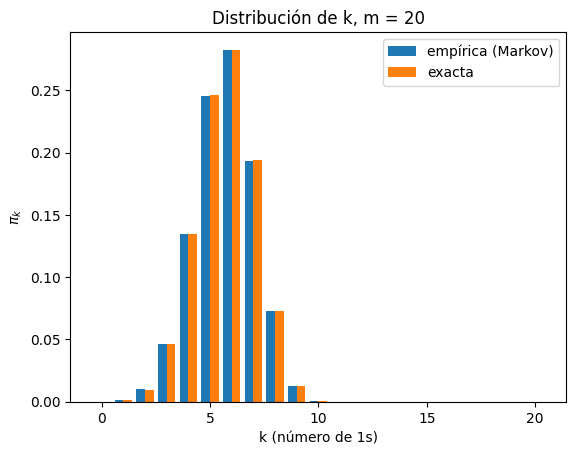

Distancia total variación: 0.0015326154649652984


In [9]:
# Validación: la distribución empírica de #unos debe parecerse a pi_k exacta
m, n = 20, 400_000
y, n_unos = [0] * m, 0
for _ in range(10 * m):
    n_unos = paso(y, n_unos, m)
conteo = np.zeros(m + 1)
for _ in range(n):
    n_unos = paso(y, n_unos, m)
    conteo[n_unos] += 1
emp = conteo / n
_, pi_ex = distribucion_exacta(m)

ks = np.arange(m + 1)
plt.bar(ks - 0.2, emp, width=0.4, label="empírica (Markov)")
plt.bar(ks + 0.2, pi_ex, width=0.4, label="exacta")
plt.xlabel("k (número de 1s)"); plt.ylabel(r"$\pi_k$"); plt.title(f"Distribución de k, m = {m}")
plt.legend(); plt.show()
print("Distancia total variación:", 0.5 * np.abs(emp - np.array(pi_ex)).sum())

## 6. Conclusiones

* Para $m=4$ hay 8 buenas cadenas y $\mu = 1.25$.
* La **aceptación y rechazo** funciona para $m$ pequeño, pero su tasa de aceptación $N_m/2^m$ decae exponencialmente;
  para $m=100$ es $\approx 10^{-9}$, así que no es viable.
* La **cadena de Markov** nunca sale del conjunto de buenas cadenas y su distribución estacionaria es uniforme
  (todos los vértices tienen peso total $m$), por lo que el promedio de $r(Y_t)$ converge a $\mu$.
  Cada paso cuesta $O(1)$, y las estimaciones coinciden con el valor exacto obtenido por la fórmula combinatoria.
* Observación: las muestras de la cadena están correlacionadas, por eso se usa un burn-in y más pasos que en muestreo independiente.